# EDA  Baseline — Pipeline USD/PEN

Este notebook consolida el análisis exploratorio, el baseline mínimo y los experimentos A/B solicitados para la Semana 5.

**Objetivo:** evaluar si las señales generadas a partir de sentimiento de noticias macroeconómicas tienen capacidad preliminar para alinearse con la dirección del USD/PEN.

El notebook está diseñado para ejecutarse localmente desde la carpeta `notebooks/` del repositorio.

## 0. Configuración inicial

En esta sección se definen rutas, parámetros de fechas y carpetas de salida.  
Puedes modificar `START_DATE` y `END_DATE` para acotar el análisis.

In [1]:
from pathlib import Path
from datetime import datetime
import json
import time
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

warnings.filterwarnings("ignore")

# =====================
# PARÁMETROS EDITABLES
# =====================
START_DATE = "2025-07-01"
END_DATE = "2026-05-08"

RANDOM_SEED = 42
TEST_SIZE_RATIO = 0.30

NOTEBOOK_DIR = Path.cwd()
PROJECT_ROOT = NOTEBOOK_DIR.parent if NOTEBOOK_DIR.name == "notebooks" else NOTEBOOK_DIR

DATA_DIR = PROJECT_ROOT / "data"
PROCESSED_DIR = DATA_DIR / "processed"
MARKET_DIR = DATA_DIR / "market"
FIGS_DIR = PROJECT_ROOT / "figs"
LOGS_DIR = PROJECT_ROOT / "logs"

FIGS_DIR.mkdir(exist_ok=True, parents=True)
LOGS_DIR.mkdir(exist_ok=True, parents=True)

print("PROJECT_ROOT:", PROJECT_ROOT)
print("PROCESSED_DIR:", PROCESSED_DIR)
print("MARKET_DIR:", MARKET_DIR)
print("FIGS_DIR:", FIGS_DIR)
print("LOGS_DIR:", LOGS_DIR)

PROJECT_ROOT: c:\Users\Thomy\Cursos\Proyecto_1\Proyecto_Tesis_1\news-sentiment-pipeline
PROCESSED_DIR: c:\Users\Thomy\Cursos\Proyecto_1\Proyecto_Tesis_1\news-sentiment-pipeline\data\processed
MARKET_DIR: c:\Users\Thomy\Cursos\Proyecto_1\Proyecto_Tesis_1\news-sentiment-pipeline\data\market
FIGS_DIR: c:\Users\Thomy\Cursos\Proyecto_1\Proyecto_Tesis_1\news-sentiment-pipeline\figs
LOGS_DIR: c:\Users\Thomy\Cursos\Proyecto_1\Proyecto_Tesis_1\news-sentiment-pipeline\logs


## 1. Carga de datos

Se cargan los archivos generados por el pipeline.  
Si algún archivo no existe, el notebook continuará con los archivos disponibles.

In [2]:
def safe_read_csv(path):
    path = Path(path)
    if path.exists():
        df = pd.read_csv(path)
        print(f"✓ Cargado: {path.relative_to(PROJECT_ROOT)} | shape={df.shape}")
        return df
    print(f"⚠ No encontrado: {path.relative_to(PROJECT_ROOT)}")
    return None

news_clean = safe_read_csv(PROCESSED_DIR / "news_clean.csv")
news_scores = safe_read_csv(PROCESSED_DIR / "news_scores.csv")
daily_sentiment = safe_read_csv(PROCESSED_DIR / "daily_sentiment.csv")
compare_fx = safe_read_csv(PROCESSED_DIR / "compare_sentiment_vs_fx.csv")
fx_local = safe_read_csv(MARKET_DIR / "usdpen_yahoo.csv")

print("\nColumnas disponibles:")
if news_clean is not None:
    print("news_clean:", news_clean.columns.tolist())
if news_scores is not None:
    print("news_scores:", news_scores.columns.tolist())
if daily_sentiment is not None:
    print("daily_sentiment:", daily_sentiment.columns.tolist())
if compare_fx is not None:
    print("compare_sentiment_vs_fx:", compare_fx.columns.tolist())
if fx_local is not None:
    print("usdpen_yahoo:", fx_local.columns.tolist())

✓ Cargado: data\processed\news_clean.csv | shape=(2906, 10)
✓ Cargado: data\processed\news_scores.csv | shape=(2849, 7)
✓ Cargado: data\processed\daily_sentiment.csv | shape=(122, 8)
✓ Cargado: data\processed\compare_sentiment_vs_fx.csv | shape=(90, 13)
✓ Cargado: data\market\usdpen_yahoo.csv | shape=(223, 7)

Columnas disponibles:
news_clean: ['news_id', 'source', 'url', 'published_at', 'fetched_at', 'title_raw', 'body_raw', 'content_hash', 'lang_hint', 'reliability_weight']
news_scores: ['news_id', 'sentiment_model', 'sentiment_label', 'p_pos', 'p_neu', 'p_neg', 'language']
daily_sentiment: ['date', 'asset', 'n_news_total', 'sent_index_mean', 'sent_index_strength', 'share_pos', 'share_neg', 'share_neu']
compare_sentiment_vs_fx: ['date', 'asset', 'n_news_total', 'sent_index_mean', 'sent_index_strength', 'share_pos', 'share_neg', 'share_neu', 'open', 'close', 'signal', 'real_dir', 'hit']
usdpen_yahoo: ['date', 'Adj Close', 'close', 'high', 'low', 'open', 'volume']


## 2. Versión de datos y control de calidad inicial

Aquí se registra el tamaño de cada archivo y la ventana temporal disponible.  
Esto ayuda a demostrar reproducibilidad.

In [3]:
data_version = {"generated_at": datetime.now().isoformat(), "files": {}}

for name, df in {
    "news_clean": news_clean,
    "news_scores": news_scores,
    "daily_sentiment": daily_sentiment,
    "compare_fx": compare_fx,
    "fx_local": fx_local
}.items():
    if df is not None:
        data_version["files"][name] = {
            "rows": int(df.shape[0]),
            "columns": int(df.shape[1]),
            "column_names": list(df.columns)
        }

with open(LOGS_DIR / "data_version.json", "w", encoding="utf-8") as f:
    json.dump(data_version, f, indent=2, ensure_ascii=False)

data_version

{'generated_at': '2026-05-08T19:26:53.989450',
 'files': {'news_clean': {'rows': 2906,
   'columns': 10,
   'column_names': ['news_id',
    'source',
    'url',
    'published_at',
    'fetched_at',
    'title_raw',
    'body_raw',
    'content_hash',
    'lang_hint',
    'reliability_weight']},
  'news_scores': {'rows': 2849,
   'columns': 7,
   'column_names': ['news_id',
    'sentiment_model',
    'sentiment_label',
    'p_pos',
    'p_neu',
    'p_neg',
    'language']},
  'daily_sentiment': {'rows': 122,
   'columns': 8,
   'column_names': ['date',
    'asset',
    'n_news_total',
    'sent_index_mean',
    'sent_index_strength',
    'share_pos',
    'share_neg',
    'share_neu']},
  'compare_fx': {'rows': 90,
   'columns': 13,
   'column_names': ['date',
    'asset',
    'n_news_total',
    'sent_index_mean',
    'sent_index_strength',
    'share_pos',
    'share_neg',
    'share_neu',
    'open',
    'close',
    'signal',
    'real_dir',
    'hit']},
  'fx_local': {'rows': 223,

## 3. Preparación del dataset diario

Para la generación de señales se trabaja principalmente con `daily_sentiment.csv`, porque contiene el sentimiento agregado por fecha.

Variables clave:

- `sent_index_mean`: índice promedio diario de sentimiento.
- `n_news_total`: cantidad de noticias del día.
- `share_pos`, `share_neg`, `share_neu`: proporción de noticias positivas, negativas y neutrales.

In [4]:
if daily_sentiment is None:
    raise FileNotFoundError("No se encontró data/processed/daily_sentiment.csv. Ejecuta primero el pipeline.")

df_daily = daily_sentiment.copy()

if "date" not in df_daily.columns:
    raise KeyError("daily_sentiment.csv debe contener una columna 'date'.")

df_daily["date"] = pd.to_datetime(df_daily["date"], errors="coerce").dt.normalize()
df_daily = df_daily.dropna(subset=["date"]).sort_values("date").reset_index(drop=True)

if START_DATE is not None:
    df_daily = df_daily[df_daily["date"] >= pd.to_datetime(START_DATE).normalize()]
if END_DATE is not None:
    df_daily = df_daily[df_daily["date"] <= pd.to_datetime(END_DATE).normalize()]

print("Fechas consideradas:")
print("Inicio:", df_daily["date"].min())
print("Fin:", df_daily["date"].max())
print("Filas:", len(df_daily))
display(df_daily.head())

Fechas consideradas:
Inicio: 2025-07-03 00:00:00
Fin: 2026-05-08 00:00:00
Filas: 122


,date,asset,n_news_total,sent_index_mean,sent_index_strength,share_pos,share_neg,share_neu
0,2025-07-03,USD/PEN,28,0.115051,0.086935,0.035714,0.0,0.964286
1,2025-07-07,USD/PEN,27,0.167342,0.109434,0.037037,0.0,0.962963
2,2025-07-09,USD/PEN,28,0.106546,0.081561,0.035714,0.0,0.964286
3,2025-07-14,USD/PEN,29,0.152271,0.106098,0.068966,0.0,0.931034
4,2025-07-16,USD/PEN,28,0.189611,0.134425,0.142857,0.0,0.857143


## 4. Estadísticas descriptivas básicas

Se revisan tamaños, nulos, duplicados y resumen estadístico de las variables numéricas.

In [5]:
print("Shape:", df_daily.shape)
print("\nNulos:")
display(df_daily.isnull().sum())

print("\nDuplicados por fecha:", df_daily["date"].duplicated().sum())

print("\nResumen estadístico:")
display(df_daily.describe(include="all"))

Shape: (122, 8)

Nulos:


date                   0
asset                  0
n_news_total           0
sent_index_mean        0
sent_index_strength    0
share_pos              0
share_neg              0
share_neu              0
dtype: int64


Duplicados por fecha: 0

Resumen estadístico:


,date,asset,n_news_total,sent_index_mean,sent_index_strength,share_pos,share_neg,share_neu
count,122,122,122.000000,122.000000,122.000000,122.000000,122.000000,122.000000
unique,NaN,1,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,USD/PEN,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,122,NaN,NaN,NaN,NaN,NaN,NaN
mean,2025-12-19 00:59:00.983606,NaN,24.008197,0.084245,0.059193,0.049536,0.036866,0.913598
min,2025-07-03 00:00:00,NaN,1.000000,-0.933797,-0.889425,0.000000,0.000000,0.000000
25%,2025-09-06 06:00:00,NaN,25.000000,0.069893,0.058838,0.000000,0.000000,0.928571
50%,2026-01-02 12:00:00,NaN,28.000000,0.105883,0.081738,0.034483,0.000000,0.964286
75%,2026-03-13 12:00:00,NaN,29.000000,0.136590,0.098135,0.068391,0.000000,1.000000
max,2026-05-08 00:00:00,NaN,137.000000,0.556626,0.318593,1.000000,1.000000,1.000000


## 5. Distribución de variables clave

Se visualizan:

- índice de sentimiento diario;
- proporción de noticias positivas, negativas y neutrales.

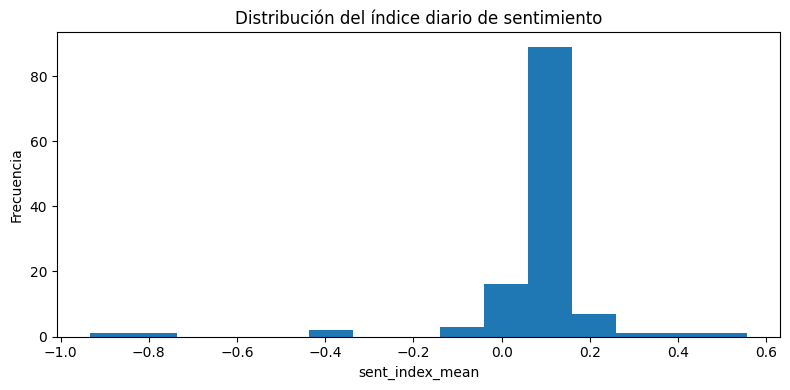

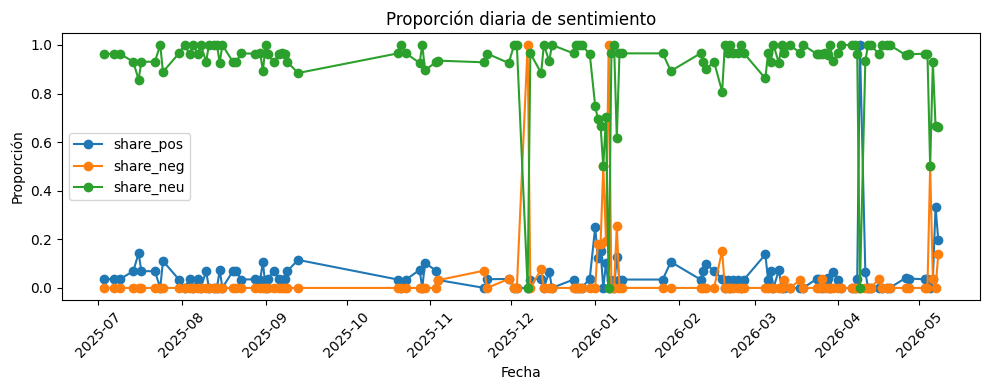

In [6]:
plt.figure(figsize=(8,4))
plt.hist(df_daily["sent_index_mean"], bins=15)
plt.title("Distribución del índice diario de sentimiento")
plt.xlabel("sent_index_mean")
plt.ylabel("Frecuencia")
plt.tight_layout()
plt.savefig(FIGS_DIR / "dist_sent_index_mean.png", dpi=150)
plt.show()

#if "n_news_total" in df_daily.columns:
#    plt.figure(figsize=(10,4))
#    plt.bar(df_daily["date"], df_daily["n_news_total"])
#    plt.title("Número de noticias por día")
#    plt.xlabel("Fecha")
#    plt.ylabel("Cantidad de noticias")
#    plt.xticks(rotation=45)
#    plt.tight_layout()
#    plt.savefig(FIGS_DIR / "news_per_day.png", dpi=150)
#    plt.show()

share_cols = [c for c in ["share_pos", "share_neg", "share_neu"] if c in df_daily.columns]
if share_cols:
    plt.figure(figsize=(10,4))
    for c in share_cols:
        plt.plot(df_daily["date"], df_daily[c], marker="o", label=c)
    plt.title("Proporción diaria de sentimiento")
    plt.xlabel("Fecha")
    plt.ylabel("Proporción")
    plt.legend()
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.savefig(FIGS_DIR / "daily_sentiment_shares.png", dpi=150)
    plt.show()

### Interpretación del EDA

El EDA permite revisar si existen suficientes datos por día y si el índice de sentimiento presenta variación.  
Esto es importante porque una señal financiera útil debe responder a cambios en el entorno informativo y no permanecer constante.

**Riesgos identificados:**

- **Desbalance:** puede haber predominio de una clase o señal.
- **Leakage:** se debe evitar usar información futura para predecir fechas anteriores.
- **Drift:** el contexto macroeconómico cambia, por lo que el desempeño puede variar entre periodos.

## 6. Feature engineering para señales

Se construyen variables simples:

- `lag_sent_1`: sentimiento del día anterior.
- `lag_sent_2`: sentimiento de dos días atrás.
- `rolling_sent_3`: promedio móvil de 3 días.
- `volatility_sent_3`: volatilidad del sentimiento en ventana de 3 días.
- `n_news_total`: volumen de noticias.

La variable objetivo se define como:

- `1`: sentimiento diario por encima de la mediana.
- `0`: sentimiento diario por debajo o igual a la mediana.

In [8]:
df_model = df_daily.copy()

median_sent = df_model["sent_index_mean"].median()
df_model["target"] = (df_model["sent_index_mean"] > median_sent).astype(int)

df_model["lag_sent_1"] = df_model["sent_index_mean"].shift(1)
df_model["lag_sent_2"] = df_model["sent_index_mean"].shift(2)
df_model["rolling_sent_3"] = df_model["sent_index_mean"].rolling(3).mean()
df_model["volatility_sent_3"] = df_model["sent_index_mean"].rolling(3).std()

if "n_news_total" not in df_model.columns:
    df_model["n_news_total"] = 1

for col in ["share_pos", "share_neg", "share_neu"]:
    if col not in df_model.columns:
        df_model[col] = 0.0

df_model = df_model.dropna().reset_index(drop=True)

print("Distribución target:")
display(df_model["target"].value_counts())
display(df_model.head())

Distribución target:


target
0    61
1    59
Name: count, dtype: int64

,date,asset,n_news_total,sent_index_mean,sent_index_strength,share_pos,share_neg,share_neu,target,lag_sent_1,lag_sent_2,rolling_sent_3,volatility_sent_3
0,2025-07-09,USD/PEN,28,0.106546,0.081561,0.035714,0.0,0.964286,1,0.167342,0.115051,0.129646,0.032921
1,2025-07-14,USD/PEN,29,0.152271,0.106098,0.068966,0.0,0.931034,1,0.106546,0.167342,0.142053,0.031660
2,2025-07-16,USD/PEN,28,0.189611,0.134425,0.142857,0.0,0.857143,1,0.152271,0.106546,0.149476,0.041603
3,2025-07-17,USD/PEN,29,0.105031,0.079039,0.068966,0.0,0.931034,0,0.189611,0.152271,0.148971,0.042386
4,2025-07-22,USD/PEN,29,0.136440,0.098304,0.068966,0.0,0.931034,1,0.105031,0.189611,0.143694,0.042754


## 7. Split temporal

La validación se hace con **holdout temporal**, respetando el orden cronológico.  
Esto evita leakage, porque el modelo entrena con fechas anteriores y evalúa en fechas posteriores.

In [9]:
if len(df_model) < 6:
    print("⚠ Advertencia: hay pocas observaciones para entrenamiento/evaluación. Los resultados serán preliminares.")

split_idx = int(len(df_model) * (1 - TEST_SIZE_RATIO))
split_idx = max(1, min(split_idx, len(df_model) - 1))

train_df = df_model.iloc[:split_idx].copy()
test_df = df_model.iloc[split_idx:].copy()

print("Train:", train_df["date"].min(), "→", train_df["date"].max(), "| filas:", len(train_df))
print("Test :", test_df["date"].min(), "→", test_df["date"].max(), "| filas:", len(test_df))

y_train = train_df["target"]
y_test = test_df["target"]
dates_test = test_df["date"]

Train: 2025-07-09 00:00:00 → 2026-03-06 00:00:00 | filas: 84
Test : 2026-03-07 00:00:00 → 2026-05-08 00:00:00 | filas: 36


## 8. Baseline mínimo ejecutado

Se entrenan modelos simples:

1. **DummyClassifier:** predice la clase más frecuente.
2. **Regla de sentimiento:** usa el signo del sentimiento.
3. **Logistic Regression:** modelo simple, interpretable y adecuado como baseline de clasificación.

La métrica principal es **F1-score**, porque el dataset puede estar desbalanceado.

In [10]:
def compute_metrics(y_true, y_pred, model_name, elapsed_time=None):
    return {
        "model": model_name,
        "accuracy": accuracy_score(y_true, y_pred),
        "f1_weighted": f1_score(y_true, y_pred, average="weighted", zero_division=0),
        "f1_binary": f1_score(y_true, y_pred, zero_division=0),
        "n_test": len(y_true),
        "elapsed_seconds": elapsed_time
    }

predictions = {}
models_results = []

start_time = time.time()
dummy = DummyClassifier(strategy="most_frequent")
dummy.fit(train_df[["sent_index_mean"]], y_train)
y_pred_dummy = dummy.predict(test_df[["sent_index_mean"]])
elapsed = time.time() - start_time

predictions["Dummy most_frequent"] = y_pred_dummy
models_results.append(compute_metrics(y_test, y_pred_dummy, "Dummy most_frequent", elapsed))

start_time = time.time()
y_pred_rule = (test_df["sent_index_mean"] > median_sent).astype(int).values
elapsed = time.time() - start_time

predictions["Rule sentiment"] = y_pred_rule
models_results.append(compute_metrics(y_test, y_pred_rule, "Rule sentiment", elapsed))

base_features = ["lag_sent_1"]
X_train_base = train_df[base_features]
X_test_base = test_df[base_features]

start_time = time.time()
lr_base = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(class_weight="balanced", random_state=RANDOM_SEED))
])
lr_base.fit(X_train_base, y_train)
y_pred_lr_base = lr_base.predict(X_test_base)
elapsed = time.time() - start_time

predictions["Logistic baseline"] = y_pred_lr_base
models_results.append(compute_metrics(y_test, y_pred_lr_base, "Logistic baseline", elapsed))

metrics_df = pd.DataFrame(models_results)
display(metrics_df)

for name, pred in predictions.items():
    print("\nModelo:", name)
    print(classification_report(y_test, pred, zero_division=0))
    print(confusion_matrix(y_test, pred))

,model,accuracy,f1_weighted,f1_binary,n_test,elapsed_seconds
0,Dummy most_frequent,0.388889,0.217778,0.560000,36,0.003015
1,Rule sentiment,1.000000,1.000000,1.000000,36,0.000995
2,Logistic baseline,0.444444,0.435845,0.473684,36,0.019534



Modelo: Dummy most_frequent
              precision    recall  f1-score   support

           0       0.00      0.00      0.00        22
           1       0.39      1.00      0.56        14

    accuracy                           0.39        36
   macro avg       0.19      0.50      0.28        36
weighted avg       0.15      0.39      0.22        36

[[ 0 22]
 [ 0 14]]

Modelo: Rule sentiment
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        22
           1       1.00      1.00      1.00        14

    accuracy                           1.00        36
   macro avg       1.00      1.00      1.00        36
weighted avg       1.00      1.00      1.00        36

[[22  0]
 [ 0 14]]

Modelo: Logistic baseline
              precision    recall  f1-score   support

           0       0.58      0.32      0.41        22
           1       0.38      0.64      0.47        14

    accuracy                           0.44        36
   macro a

## 9. Resultados y gráfica central

Se comparan los modelos mediante Accuracy y F1-score.

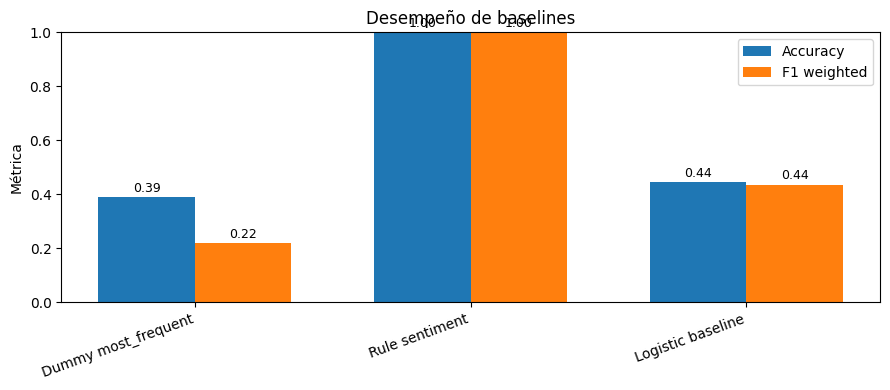

,model,accuracy,f1_weighted,f1_binary,n_test,elapsed_seconds
0,Dummy most_frequent,0.388889,0.217778,0.560000,36,0.003015
1,Rule sentiment,1.000000,1.000000,1.000000,36,0.000995
2,Logistic baseline,0.444444,0.435845,0.473684,36,0.019534


In [11]:
plt.figure(figsize=(9,4))
bar_width = 0.35
x = np.arange(len(metrics_df))

plt.bar(x - bar_width/2, metrics_df["accuracy"], width=bar_width, label="Accuracy")
plt.bar(x + bar_width/2, metrics_df["f1_weighted"], width=bar_width, label="F1 weighted")

plt.xticks(x, metrics_df["model"], rotation=20, ha="right")
plt.ylim(0, 1)
plt.title("Desempeño de baselines")
plt.ylabel("Métrica")
plt.legend()

for i, row in metrics_df.iterrows():
    plt.text(i - bar_width/2, row["accuracy"] + 0.02, f"{row['accuracy']:.2f}", ha="center", fontsize=9)
    plt.text(i + bar_width/2, row["f1_weighted"] + 0.02, f"{row['f1_weighted']:.2f}", ha="center", fontsize=9)

plt.tight_layout()
plt.savefig(FIGS_DIR / "baseline_metrics_comparison.png", dpi=150)
plt.show()

display(metrics_df)

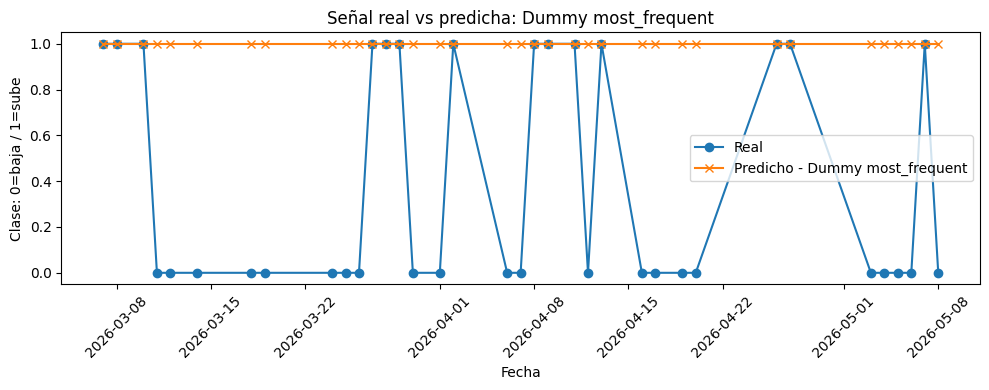

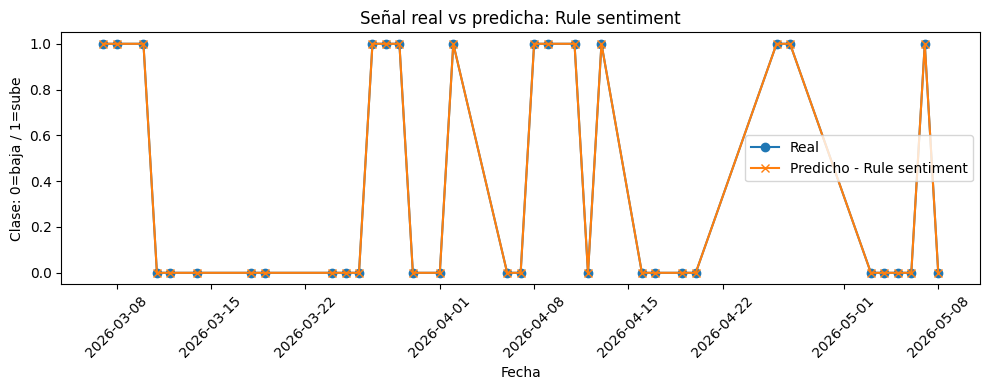

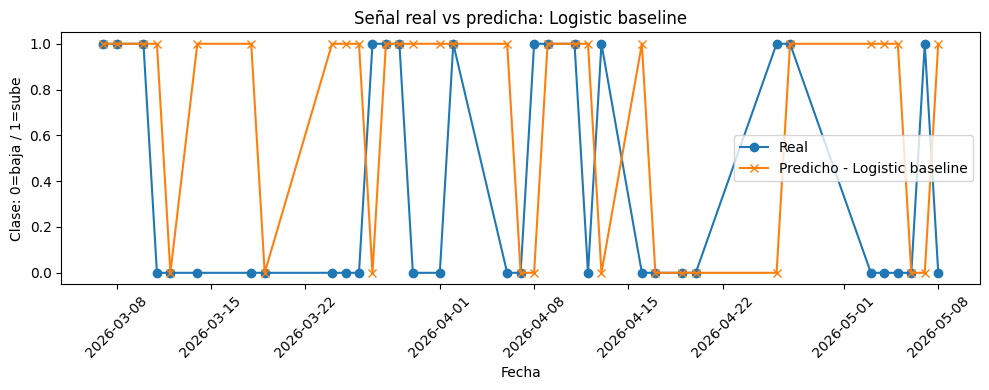

In [12]:
for model_name, y_pred in predictions.items():
    plt.figure(figsize=(10,4))
    plt.plot(dates_test, y_test.values, marker="o", label="Real")
    plt.plot(dates_test, y_pred, marker="x", label=f"Predicho - {model_name}")
    plt.title(f"Señal real vs predicha: {model_name}")
    plt.xlabel("Fecha")
    plt.ylabel("Clase: 0=baja / 1=sube")
    plt.xticks(rotation=45)
    plt.legend()
    plt.tight_layout()
    safe_name = model_name.lower().replace(" ", "_").replace("/", "_")
    plt.savefig(FIGS_DIR / f"signal_vs_prediction_{safe_name}.png", dpi=150)
    plt.show()

### Interpretación de resultados

Los resultados del baseline deben leerse como una referencia inicial.  
Si el desempeño es bajo, no significa que el proyecto falle; significa que el modelo mínimo todavía no captura bien la dinámica del mercado o de la señal.

Este resultado permite justificar mejoras futuras como:

- ampliar la ventana histórica;
- incorporar más variables macroeconómicas;
- ponderar por fuente;
- usar banda neutral;
- mejorar el target de evaluación.

## 10. Comparación opcional contra USD/PEN real

Esta sección compara la señal del modelo contra la dirección real del USD/PEN usando `data/market/usdpen_yahoo.csv` si está disponible.

In [13]:
df_fx_eval = None
fx = None

if fx_local is not None:
    fx = fx_local.copy()
    fx.columns = [c.lower().replace(" ", "_") for c in fx.columns]

    date_candidates = ["date", "datetime", "timestamp"]
    fx_date_col = next((c for c in date_candidates if c in fx.columns), None)

    close_candidates = ["close", "adj_close", "usdpen_close"]
    fx_close_col = next((c for c in close_candidates if c in fx.columns), None)

    if fx_date_col and fx_close_col:
        fx["date"] = pd.to_datetime(fx[fx_date_col], errors="coerce").dt.normalize()
        fx["usdpen_close"] = pd.to_numeric(fx[fx_close_col], errors="coerce")
        fx = fx.dropna(subset=["date", "usdpen_close"]).sort_values("date")
        fx["fx_change"] = fx["usdpen_close"].diff()
        fx["fx_direction"] = (fx["fx_change"] > 0).astype(int)
        fx = fx.dropna(subset=["fx_change"])

        df_fx_eval = test_df[["date"]].merge(
            fx[["date", "usdpen_close", "fx_change", "fx_direction"]],
            on="date",
            how="left"
        ).dropna(subset=["fx_direction"])

        print("Filas para evaluación contra USD/PEN:", len(df_fx_eval))
        display(df_fx_eval)
    else:
        print("⚠ No se detectaron columnas de fecha/cierre en usdpen_yahoo.csv")
else:
    print("⚠ No existe data/market/usdpen_yahoo.csv")

Filas para evaluación contra USD/PEN: 26


,date,usdpen_close,fx_change,fx_direction
2,2026-03-10,3.487000,0.129694,1.0
3,2026-03-11,3.432000,-0.055000,0.0
4,2026-03-12,3.417000,-0.015000,0.0
6,2026-03-18,3.416000,-0.011000,0.0
7,2026-03-19,3.426000,0.010000,1.0
8,2026-03-24,3.471000,0.088608,1.0
9,2026-03-25,3.383441,-0.087559,0.0
10,2026-03-26,3.460000,0.076559,1.0
11,2026-03-27,3.387681,-0.072319,0.0
14,2026-03-30,3.402798,0.015117,1.0


,model,accuracy_vs_fx,f1_weighted_vs_fx,n_eval
0,Dummy most_frequent,0.384615,0.213675,26
1,Rule sentiment,0.461538,0.447461,26
2,Logistic baseline,0.461538,0.461538,26


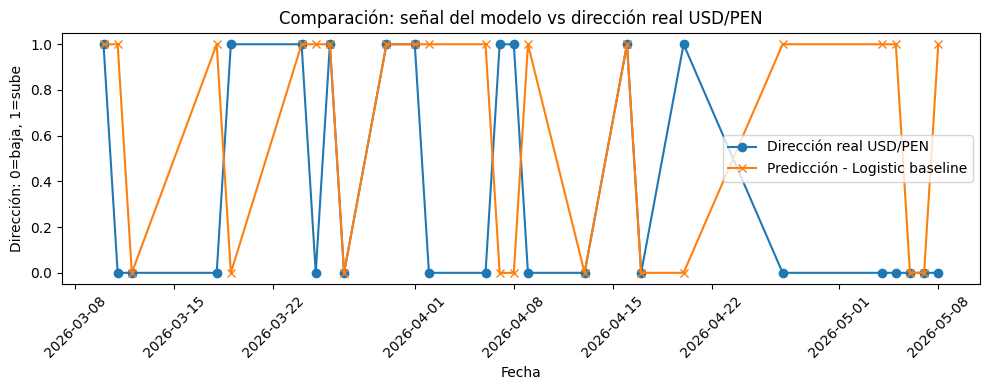

In [14]:
if df_fx_eval is not None and len(df_fx_eval) > 0:
    common_dates = df_fx_eval["date"]

    fx_results = []
    for model_name, y_pred in predictions.items():
        pred_series = pd.Series(y_pred, index=test_df["date"])
        y_pred_aligned = pred_series.loc[common_dates].values
        y_true_fx = df_fx_eval["fx_direction"].astype(int).values

        fx_results.append({
            "model": model_name,
            "accuracy_vs_fx": accuracy_score(y_true_fx, y_pred_aligned),
            "f1_weighted_vs_fx": f1_score(y_true_fx, y_pred_aligned, average="weighted", zero_division=0),
            "n_eval": len(y_true_fx)
        })

    fx_metrics_df = pd.DataFrame(fx_results)
    display(fx_metrics_df)

    best_fx_model = fx_metrics_df.sort_values("f1_weighted_vs_fx", ascending=False).iloc[0]["model"]
    y_pred_best = pd.Series(predictions[best_fx_model], index=test_df["date"]).loc[common_dates].values

    plt.figure(figsize=(10,4))
    plt.plot(df_fx_eval["date"], df_fx_eval["fx_direction"].values, marker="o", label="Dirección real USD/PEN")
    plt.plot(df_fx_eval["date"], y_pred_best, marker="x", label=f"Predicción - {best_fx_model}")
    plt.title("Comparación: señal del modelo vs dirección real USD/PEN")
    plt.xlabel("Fecha")
    plt.ylabel("Dirección: 0=baja, 1=sube")
    plt.xticks(rotation=45)
    plt.legend()
    plt.tight_layout()
    plt.savefig(FIGS_DIR / "modelo_vs_usdpen_real.png", dpi=150)
    plt.show()
else:
    print("No hay suficientes datos FX para comparar con el conjunto de test.")

### Interpretación de la comparación con USD/PEN

Esta evaluación permite medir si la señal del modelo coincide con la dirección real del tipo de cambio.  
Si el desempeño es bajo, se interpreta como una limitación del baseline y como evidencia de que el sentimiento por sí solo no captura toda la dinámica cambiaria.

## 11. EDA por noticia y cuadro diario explicado

Se intenta unir `news_clean.csv` con `news_scores.csv` para analizar noticias individuales.

Si los `news_id` no coinciden, el notebook lo reportará y continuará con el análisis diario agregado.

In [15]:
df_news = None

if news_clean is not None and news_scores is not None and "news_id" in news_clean.columns and "news_id" in news_scores.columns:
    clean_ids = set(news_clean["news_id"].astype(str).str.strip())
    score_ids = set(news_scores["news_id"].astype(str).str.strip())
    print("Coincidencias news_id:", len(clean_ids.intersection(score_ids)))

    news_clean_tmp = news_clean.copy()
    news_scores_tmp = news_scores.copy()
    news_clean_tmp["news_id_norm"] = news_clean_tmp["news_id"].astype(str).str.strip()
    news_scores_tmp["news_id_norm"] = news_scores_tmp["news_id"].astype(str).str.strip()

    df_news = news_clean_tmp.merge(
        news_scores_tmp,
        on="news_id_norm",
        how="inner",
        suffixes=("", "_score")
    )

    if len(df_news) > 0:
        date_candidates = ["published_at", "date", "pub_date", "created_at", "fecha"]
        date_col = next((c for c in date_candidates if c in df_news.columns), None)

        if date_col:
            df_news["date"] = pd.to_datetime(df_news[date_col], errors="coerce").dt.normalize()
            df_news["sentiment_score"] = df_news["p_pos"] - df_news["p_neg"]
            df_news = df_news.dropna(subset=["date"])

            if START_DATE is not None:
                df_news = df_news[df_news["date"] >= pd.to_datetime(START_DATE).normalize()]
            if END_DATE is not None:
                df_news = df_news[df_news["date"] <= pd.to_datetime(END_DATE).normalize()]

            print("Noticias válidas:", df_news.shape)
            display(df_news.head())
        else:
            print("⚠ No se encontró columna de fecha en noticias.")
    else:
        print("⚠ No hay coincidencias entre news_clean y news_scores. Se omite EDA por noticia.")
else:
    print("⚠ No están disponibles news_clean/news_scores o falta news_id.")

Coincidencias news_id: 2849
Noticias válidas: (36, 20)


,news_id,source,url,published_at,fetched_at,title_raw,body_raw,content_hash,lang_hint,reliability_weight,news_id_norm,news_id_score,sentiment_model,sentiment_label,p_pos,p_neu,p_neg,language,date,sentiment_score
0,8999b41072fe67deb6fe281f1003c50a,Financial Times - Global Economy,https://www.ft.com/content/245e5c30-0a0b-43cd-...,"Fri, 08 May 2026 20:07:09 GMT",2026-05-08T23:41:52.812298+00:00,"US adds 115,000 jobs in April as labour market...",Hiring exceeds Wall Street forecasts for secon...,962e33c4ed6734bb3105c0bab8898fc8e08d6e49e65cf4...,en,1.3,8999b41072fe67deb6fe281f1003c50a,8999b41072fe67deb6fe281f1003c50a,ProsusAI/finbert,pos,0.631712,0.024121,0.344167,en,2026-05-08,0.287545
1,2667a8ed6f2d4b6cabc916f1109cca7c,Financial Times - Global Economy,https://www.ft.com/content/28233206-79b5-4bd7-...,"Fri, 08 May 2026 17:48:30 GMT",2026-05-08T23:41:52.812298+00:00,Strait and narrower,The window to prevent a global economic disast...,f6a8dbdb569186d7e12d08e58fae62b05d8a0c39c4607c...,en,1.3,2667a8ed6f2d4b6cabc916f1109cca7c,2667a8ed6f2d4b6cabc916f1109cca7c,ProsusAI/finbert,neu,0.154801,0.755229,0.089970,en,2026-05-08,0.064831
2,29064591336b20d1e9f13b6951bcafd5,Financial Times - Global Economy,https://www.ft.com/content/60f60089-9486-481c-...,"Fri, 08 May 2026 15:25:15 GMT",2026-05-08T23:41:52.812298+00:00,Markets are banking on the ‘Bliss trade’,A belief in resilience underwritten by big las...,d8092623978921af8eaffd690f4cc82e8e2bb4e96fb5df...,en,1.3,29064591336b20d1e9f13b6951bcafd5,29064591336b20d1e9f13b6951bcafd5,ProsusAI/finbert,pos,0.810878,0.069820,0.119302,en,2026-05-08,0.691576
3,82c53ad4cda82e6d944b42f47b32dc8e,Financial Times - Global Economy,https://www.ft.com/content/2bcaf369-ce39-45f5-...,"Fri, 08 May 2026 13:42:21 GMT",2026-05-08T23:41:52.812298+00:00,US labour market stable in April,Healthy payrolls growth and steady unemploymen...,4331103025ef19080767349e55d6fc4192d1f018c25226...,en,1.3,82c53ad4cda82e6d944b42f47b32dc8e,82c53ad4cda82e6d944b42f47b32dc8e,ProsusAI/finbert,pos,0.691266,0.073457,0.235277,en,2026-05-08,0.455989
4,ce34ddeafdf161ad81da2003e96046ad,Financial Times - Global Economy,https://www.ft.com/content/bba96591-1928-4f71-...,"Fri, 08 May 2026 11:00:05 GMT",2026-05-08T23:41:52.812298+00:00,The energy shock is not all about price,Low stocks of crude and products in Europe are...,dde051f58e5fd2c8312aeaedd35604d3e0509d0d42e56f...,en,1.3,ce34ddeafdf161ad81da2003e96046ad,ce34ddeafdf161ad81da2003e96046ad,ProsusAI/finbert,neg,0.053435,0.057420,0.889145,en,2026-05-08,-0.835710


In [16]:
if df_news is not None and len(df_news) > 0:
    daily_news = (
        df_news
        .groupby("date")
        .agg(
            n_news=("news_id_norm", "count"),
            sentiment_score_mean=("sentiment_score", "mean"),
            sentiment_dominante=("sentiment_label", lambda x: x.value_counts().idxmax()),
            n_positive=("sentiment_label", lambda x: (x == "positive").sum()),
            n_neutral=("sentiment_label", lambda x: (x == "neutral").sum()),
            n_negative=("sentiment_label", lambda x: (x == "negative").sum()),
        )
        .reset_index()
    )

    if fx is not None:
        daily_news_fx = daily_news.merge(
            fx[["date", "usdpen_close", "fx_change", "fx_direction"]],
            on="date",
            how="left"
        )
    else:
        daily_news_fx = daily_news

    display(daily_news_fx)

    cols = ["date", "source", "title_raw", "sentiment_label", "sentiment_score", "p_pos", "p_neu", "p_neg"]
    available_cols = [c for c in cols if c in df_news.columns]
    display(df_news[available_cols].sort_values(["date", "sentiment_score"], ascending=[True, False]).head(30))
else:
    print("No se generó cuadro por noticia porque no existen noticias válidas después del merge.")

,date,n_news,sentiment_score_mean,sentiment_dominante,n_positive,n_neutral,n_negative,usdpen_close,fx_change,fx_direction
0,2026-05-01,3,-0.586102,neg,0,0,0,3.5075,-0.0155,0
1,2026-05-05,1,-0.930748,neg,0,0,0,3.5040,-0.0030,0
2,2026-05-06,2,-0.212078,neg,0,0,0,3.4880,-0.0160,0
3,2026-05-07,15,-0.136037,neg,0,0,0,3.4620,-0.0260,0
4,2026-05-08,15,-0.064867,pos,0,0,0,3.4570,-0.0050,0


,date,source,title_raw,sentiment_label,sentiment_score,p_pos,p_neu,p_neg
35,2026-05-01,CNBC - Economy,Inside the Fed: Powell vows he won't be a 'sha...,neu,0.035409,0.054318,0.926774,0.018909
34,2026-05-01,CNBC - Economy,"Fed dissenters explain 'no' votes, saying they...",neg,-0.845766,0.021910,0.110414,0.867676
33,2026-05-01,CNBC - Economy,UK exports to U.S. plunge by 25% after Trump's...,neg,-0.947948,0.014214,0.023624,0.962162
32,2026-05-05,CNBC - Economy,Aluminum prices are surging. Here's how compan...,neg,-0.930748,0.018684,0.031884,0.949432
31,2026-05-06,CNBC - Economy,"Private payrolls rose by 109,000 in April, top...",neg,-0.178340,0.312725,0.196211,0.491065
30,2026-05-06,CNBC - Economy,Surging gas prices are hitting lower-income ho...,neg,-0.245815,0.315318,0.123549,0.561133
22,2026-05-07,Financial Times - Global Economy,Maersk warns economic impact of Iran conflict ...,pos,0.925115,0.951199,0.022717,0.026084
28,2026-05-07,CNBC - Economy,Here's what to expect from Friday's release of...,pos,0.647637,0.714396,0.218844,0.066760
18,2026-05-07,Financial Times - Global Economy,FirstFT: US fuel exports surge as pump prices ...,pos,0.479227,0.539596,0.400035,0.060369
15,2026-05-07,Financial Times - Global Economy,Chinese overseas M&A hits 5-year high despite ...,neu,0.120011,0.130856,0.858300,0.010844


### Nota metodológica sobre noticias y tipo de cambio

Con datos diarios no se puede afirmar que una noticia específica movió el tipo de cambio inmediatamente.  
Para ese análisis se necesitaría:

- hora exacta de publicación de cada noticia;
- cotización intradía del USD/PEN;
- metodología de event study.

Con los datos actuales, el análisis correcto es agregado por día.

## 12. Experimentos A/B   --- PENDIENTE POR TERMINAR

Se comparan variantes contra el baseline cambiando **una cosa por vez**: el conjunto de features.

- **Baseline:** solo `lag_sent_1`.
- **Variante 1:** agrega `lag_sent_2`.
- **Variante 2:** agrega volumen de noticias y proporciones.
- **Variante 3 opcional:** agrega promedio móvil y volatilidad.

In [17]:
experiment_specs = {
    "Baseline_lag1": ["lag_sent_1"],
    "Var1_lag1_lag2": ["lag_sent_1", "lag_sent_2"],
    "Var2_lags_volume_shares": ["lag_sent_1", "lag_sent_2", "n_news_total", "share_pos", "share_neg", "share_neu"],
    "Var3_full_temporal": ["lag_sent_1", "lag_sent_2", "rolling_sent_3", "volatility_sent_3", "n_news_total", "share_pos", "share_neg", "share_neu"]
}

ab_results = []
ab_predictions = {}

for exp_name, features in experiment_specs.items():
    features = [f for f in features if f in df_model.columns]

    X_train = train_df[features]
    X_test = test_df[features]

    start_time = time.time()
    model = Pipeline([
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(class_weight="balanced", random_state=RANDOM_SEED))
    ])

    try:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        elapsed = time.time() - start_time

        ab_predictions[exp_name] = y_pred
        ab_results.append({
            "experiment": exp_name,
            "features": ", ".join(features),
            "accuracy": accuracy_score(y_test, y_pred),
            "f1_weighted": f1_score(y_test, y_pred, average="weighted", zero_division=0),
            "f1_binary": f1_score(y_test, y_pred, zero_division=0),
            "elapsed_seconds": elapsed,
            "n_features": len(features),
            "n_train": len(y_train),
            "n_test": len(y_test)
        })
    except Exception as e:
        ab_results.append({
            "experiment": exp_name,
            "features": ", ".join(features),
            "accuracy": np.nan,
            "f1_weighted": np.nan,
            "f1_binary": np.nan,
            "elapsed_seconds": np.nan,
            "n_features": len(features),
            "n_train": len(y_train),
            "n_test": len(y_test),
            "error": str(e)
        })

ab_results_df = pd.DataFrame(ab_results)
display(ab_results_df)

,experiment,features,accuracy,f1_weighted,f1_binary,elapsed_seconds,n_features,n_train,n_test
0,Baseline_lag1,lag_sent_1,0.444444,0.435845,0.473684,0.009172,1,84,36
1,Var1_lag1_lag2,"lag_sent_1, lag_sent_2",0.388889,0.388889,0.388889,0.012025,2,84,36
2,Var2_lags_volume_shares,"lag_sent_1, lag_sent_2, n_news_total, share_po...",0.666667,0.670833,0.625000,0.008070,6,84,36
3,Var3_full_temporal,"lag_sent_1, lag_sent_2, rolling_sent_3, volati...",0.694444,0.698006,0.666667,0.008658,8,84,36


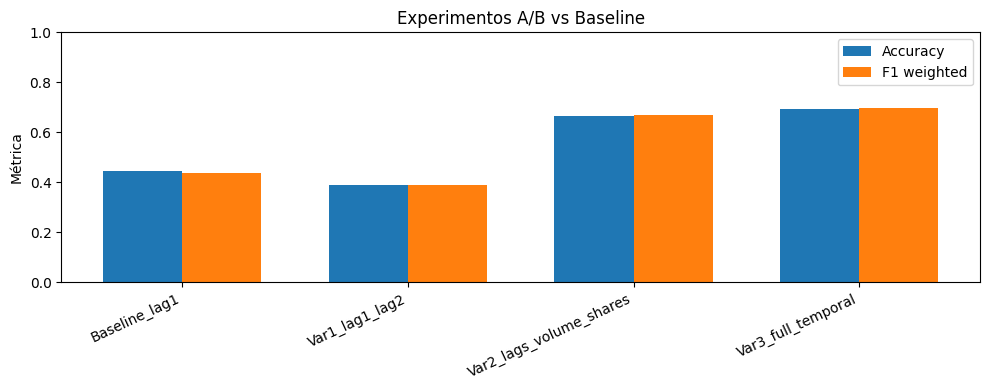

✓ Resultados guardados en:
c:\Users\Thomy\Cursos\Proyecto_1\Proyecto_Tesis_1\news-sentiment-pipeline\logs\experiments_week5.csv
c:\Users\Thomy\Cursos\Proyecto_1\Proyecto_Tesis_1\news-sentiment-pipeline\logs\metrics_baseline.txt


In [18]:
plt.figure(figsize=(10,4))
x = np.arange(len(ab_results_df))
bar_width = 0.35

plt.bar(x - bar_width/2, ab_results_df["accuracy"], width=bar_width, label="Accuracy")
plt.bar(x + bar_width/2, ab_results_df["f1_weighted"], width=bar_width, label="F1 weighted")

plt.xticks(x, ab_results_df["experiment"], rotation=25, ha="right")
plt.ylim(0, 1)
plt.title("Experimentos A/B vs Baseline")
plt.ylabel("Métrica")
plt.legend()
plt.tight_layout()
plt.savefig(FIGS_DIR / "week5_ab_experiments.png", dpi=150)
plt.show()

ab_results_df.to_csv(LOGS_DIR / "experiments_week5.csv", index=False)

with open(LOGS_DIR / "metrics_baseline.txt", "w", encoding="utf-8") as f:
    f.write("Métricas de Baseline y Experimentos A/B\n")
    f.write(f"Fecha ejecución: {datetime.now().isoformat()}\n")
    f.write(f"START_DATE: {START_DATE}\n")
    f.write(f"END_DATE: {END_DATE}\n")
    f.write(f"RANDOM_SEED: {RANDOM_SEED}\n")
    f.write(f"Split temporal: train={len(train_df)}, test={len(test_df)}\n\n")
    f.write("Baselines iniciales:\n")
    f.write(metrics_df.to_string(index=False))
    f.write("\n\nExperimentos Semana 5:\n")
    f.write(ab_results_df.to_string(index=False))

print("✓ Resultados guardados en:")
print(LOGS_DIR / "experiments_week5.csv")
print(LOGS_DIR / "metrics_baseline.txt")

### Conclusión de experimentos A/B

Los experimentos A/B permiten comparar si agregar nuevas features mejora la señal respecto al baseline.  
La evaluación se hace con el mismo split temporal para mantener comparabilidad y evitar leakage.

Si una variante mejora el F1-score o el hit-rate direccional, puede considerarse una mejora preliminar.  
Si no mejora, el resultado también es útil porque indica que esas features no aportan suficiente información en la ventana analizada.

## 13. Logs, figuras y reproducibilidad

El notebook genera automáticamente:

- `figs/baseline_metrics_comparison.png`
- `figs/signal_vs_prediction_*.png`
- `figs/modelo_vs_usdpen_real.png`
- `figs/week5_ab_experiments.png`
- `logs/metrics_baseline.txt`
- `logs/experiments_week5.csv`
- `logs/data_version.json`

Estos archivos sirven como evidencia de ejecución y reproducibilidad.

In [19]:
dates_for_fx = {
    "start_date": str(df_daily["date"].min().date()) if len(df_daily) else None,
    "end_date": str(df_daily["date"].max().date()) if len(df_daily) else None,
    "test_dates": [str(d.date()) for d in dates_test]
}

with open(LOGS_DIR / "dates_for_fx_lookup.txt", "w", encoding="utf-8") as f:
    f.write("Fechas consideradas para búsqueda de tipo de cambio USD/PEN\n")
    f.write(json.dumps(dates_for_fx, indent=2, ensure_ascii=False))

print("Fechas consideradas:")
dates_for_fx

Fechas consideradas:


{'start_date': '2025-07-03',
 'end_date': '2026-05-08',
 'test_dates': ['2026-03-07',
  '2026-03-08',
  '2026-03-10',
  '2026-03-11',
  '2026-03-12',
  '2026-03-14',
  '2026-03-18',
  '2026-03-19',
  '2026-03-24',
  '2026-03-25',
  '2026-03-26',
  '2026-03-27',
  '2026-03-28',
  '2026-03-29',
  '2026-03-30',
  '2026-04-01',
  '2026-04-02',
  '2026-04-06',
  '2026-04-07',
  '2026-04-08',
  '2026-04-09',
  '2026-04-11',
  '2026-04-12',
  '2026-04-13',
  '2026-04-16',
  '2026-04-17',
  '2026-04-19',
  '2026-04-20',
  '2026-04-26',
  '2026-04-27',
  '2026-05-03',
  '2026-05-04',
  '2026-05-05',
  '2026-05-06',
  '2026-05-07',
  '2026-05-08']}

## 14. 
